# Ритмика и обработка на корпусе "Эпоса о Гильгамеше"
Работу выполнила студентка ОП "Ассириология: языки и история древней Месопоатмии" Виктория Васильевна Ивашова (vvivashova@edu.hse.ru)



## Краткая филологическая справка о гимно-эпических произведения в аккадской литературе

**I. ТИПЫ СЛОГОВ**
1) Light — [L]: открытый слог с кратким гласным (ma, be) 
2) Heavy — [H]:
	- открытый слог с долгим гласным (lū)
    - закрытый слог с кратким гласным (šar).
3) Ultra-heavy — [U]:
    - открытый слог со стяжённым (крышечка :3) гласным (nâ) 
    - закрытый слог с долгим (māt) / стяженным гласным (dâk).


**II. ПРАВИЛА УДАРЕНИЯ**
Слог с главным ударением — [/]
ВНИМАНИЕ: шаги нужно выполнять один за другим. 
Последний слог == U  ⇒ ударение падает на (этот) последний (U-)слог iL-kâlU.
Последний слог == L/H  ⇒ ударение падает на последний не конечный H/U-слог paL-rāH-sumH 
В слове нет U-слогов, нет нет неконечных H-слогов ⇒ ударение падает на первый слог

ДОПОЛНИТЕЛЬНО:
Односложные слова (предлоги, союзы, частицы) сами по себе ударения не несут и примыкают к следующему слову.
Конечные открытые слоги со стяженным гласным (na-bû) считаются за два слога (na-bu-u), и первый из них несет ударение.

Слог с вторичным ударением — [\]:
Вторичное ударение ставится на каждый второй безударный слог от слога с главным ударением (если это не создает два ударных слога подряд).

Безударный слог — [x]


**III. РИТМИЧЕСКИЕ СТОПЫ**
- трохей: ударный+безударный слог один за другим == /x, \x == [T]
- амфибрахий: безударный+ударный+безударный == x\x, x/x == [A]
Дробление на стопы маркируется знаком [']


**IV. ПРИМЕРЫ**
<br>
1) Пример строки без аккадских "стоп-слов":<br>
    mêšunu ištēniš iḫīqūma<br>
    mê-šu-nu iš-tē-niš i-ḫī-qū-ma<br>
    U-L-L H-H-H L-H-H-L<br>
    / x ' \ x ' / x ' \ x ' / x<br>
    TTATT<br>

2) Пример строки с аккадским "стоп-слов" (обратите внимание, что стоп-слова не участвую при анализе, расстновки ударений, ритимической стопы, определения стопы):<br>
    ša nagba īmuru išdī māti<br>
    ša nag-ba ī-mu-ru iš-dī mā-ti<br>
    H-L H-L-L H-H H-L<br>
    / x ' / x ' \ / ' x / ' x<br>
    TTTTT

## Информация о программе
Данная программа должна помочь с первичной обработкой текста людям, интресующиемся ритмикой в аккадской поэзии. В результете программы на выходе создаются файлы с разобранными таблицами "Эпоса о Гильгамеше" с учтеном правил аккадской ритмики.<br>
Для корректной работы:
- положите запускаемый файл и скаченные таблицы в формате json (скачть можно по этой ссылки - https://disk.yandex.ru/d/ueA_Kvhbg43g3A)
- последовательно запустите ячейки, для удобства чтения функции разделены по разным ячейкам.
Для удобства пользователя программа пишет названия разобранных таблиц.

#### Историческая справка об "Эпосе о Гильгамеше"
Изначальная версия "Эпоса" содержала только 11 таблиц, а 12 таблица является уже поздней добавочной. Также таблицы 1-11 имеют кольцевую композицию. Но самым выжным явлеятся, то что таблицы 1-11 написаны в гимно-эпическом жанре с соблюдением ритма и ударений, в отличие от таблицы 12, которая написана в прозаическим способом, это делает не возможным дальнешнюю обработку данной таблицы.

In [1]:
#модули необходимы для работы программы
import json #для чтение файлов
import re #для работы с регулярными вражениями

In [2]:
#что-то наподобие "глобальных переменных"
#словарь с названием всех таблиц
dictionary_tablets = {
    1: "L 1 4 Standard Babylonian I.json",
    2: "L 1 4 Standard Babylonian II.json",
    3: "L 1 4 Standard Babylonian III.json",
    4: "L 1 4 Standard Babylonian IV.json",
    5: "L 1 4 Standard Babylonian V.json",
    6: "L 1 4 Standard Babylonian VI.json",
    7: "L 1 4 Standard Babylonian VII.json",
    8: "L 1 4 Standard Babylonian VIII.json",
    9: "L 1 4 Standard Babylonian IX.json",
    10: "L 1 4 Standard Babylonian X.json",
    11: "L 1 4 Standard Babylonian XI.json",
}

#гласные и их разновидности
short_vow = {'a', 'e', 'i', 'u'}
long_vow = {'ā', 'ē', 'ī', 'ū'}
ultra_long_vow = {'â', 'ê', 'î', 'û'}
all_vow = short_vow | long_vow | ultra_long_vow

#соотвествия сверхдолгих коротким и длинным для поставноки ударения
ultra_and_short = {'û': 'u', 'â': 'a', 'î': 'i', 'ê': 'e'}
ultra_and_long = {'û': 'ū', 'â': 'ā', 'î': 'ī', 'ê': 'ē'}

#стоп слова аккадского, на которые ударения не может падать
stop_words_akk = {'ma', 'wa', 'ša', 'ina', 'ana', 'kī', 'ū', 'ul', 'u', 'kīma'}

In [3]:
#функция для определения типа гласной
def vowel_type(vowel):
    if vowel in short_vow:
        return 'short'
    if vowel in long_vow:
        return 'long'
    if vowel in ultra_long_vow:
        return 'ultra long'

In [4]:
#функция для нахождение сверхдолгих наконце, чтобы правильно проставить ударения
def ultra_long_end(word):
    new_word = [] #изменное слово
    position = [] #позции, которые были изменины

    i = 0
    while i < len(word):
        if (i < len(word) - 1) and (word[i+1] in ultra_long_vow) and (i+1 == len(word) - 1):
            prev_letter = word[i] #соглсный перед сверхдолгой
            vowel = word[i+1] #сверхдолгая
            if prev_letter in all_vow: #предыдущий символ перед сверхдолгой
                consonant = ''
            else:
                consonant = prev_letter
            
            #модификая сверхдолгого
            short_vow = ultra_and_short[vowel]
            long_vow = ultra_and_long[vowel]

            #изменное слово, первый слог
            if consonant:
                new_word.append(consonant + short_vow)
            else:
                new_word.append(short_vow)
            new_word.append(long_vow)  #изменное слово 2 слог

            position.append(len(new_word) - 2)  #позиция ударного слога
            i += 2 #уже обработанные символ
        else:
            new_word.append(word[i]) #не сверхдолгие буквы 
            i += 1
        
    return ''.join(new_word), position

In [5]:
#функция для первичного ударения
def main_emphasis(types, syllables, ultra_long_positions):
    n = len(types)
    if n == 0:
        return 0
    if ultra_long_positions and ultra_long_positions[-1] < n:
        return ultra_long_positions[-1]
    #если тип слог -- 'U', ударение на нем
    if types[-1] == 'U':
        return n - 1
    #на предпоследний
    for i in range(n - 2, -1, -1):
        if types[i] in ('H', 'U'):
            return i
    
    # иначе -- на первом слоге
    return 0

In [6]:
#функция проверят ударения, чтобы не было двух подряд ударных слогов
def check_emphasis(types, main_index):
    n = len(types)
    if n <= 1:
        return []
    second = []
    
    #влево от главного ударения, считается только безударные
    step = 0
    for i in range(main_index - 1, -1, -1):
        if i != main_index and i not in second:
            step += 1
            if step % 2 == 0:  #добавляем каждый второй безударный
                second.append(i)
    
    #вправо от главного ударения
    step = 0
    for i in range(main_index + 1, n):
         if i != main_index and i not in second:
            step += 1
            if step % 2 == 0:  #каждый второй безударный
                second.append(i)
    
    return sorted(second)

In [7]:
#функция разбиение слога и определение его типа
def make_syllables(word):
    
    original_word = word
    ultra_word, ultra_long_positions = ultra_long_end(word) #сверхдолгий на конце

    #обработка (замена - для разделения на слоги)
    word_for_analysis = ultra_word.replace('-', '')

    #гласные и их позиции в слове
    vowel_position = []
    vowel_letter = []
    for i in range(len(word_for_analysis)):
        letter_word = word_for_analysis[i]
        if letter_word in all_vow:
            vowel_position.append(i)
            vowel_letter.append(letter_word)
    
    if len(vowel_position) == 0:  #если в слове нет гласного (для лакун, неполных востановлений)
        #чтобы избежать ошибок: возвращение изначального слова, считаем его как один слог
        return [original_word], ['?'], 0, []

    syllables = []
    types = []
    n = len(vowel_position)
    pos = 0

    #цикл деления
    for index_letter in range(n):
        vow_pos = vowel_position[index_letter] #гласный, который сейчас 
        before_vow = word_for_analysis[pos:vow_pos] #согласные, которые перед этой глсасной
        vowel = vowel_letter[index_letter] #сам гласный
        
        if index_letter < n - 1: #случай, когда слог не последний
            next_vow_pos = vowel_position[index_letter + 1]
            betwen_vow = word_for_analysis[vow_pos + 1:next_vow_pos] #согласные между гласными
            if betwen_vow:
                if len(betwen_vow) >= 2: #если несколько согласных, деление на слоги
                    next_cons = betwen_vow[0]
                else:
                    next_cons = ''
            else:
                next_cons = ''
                
            syl = before_vow + vowel + next_cons
            pos = vow_pos + 1 + len(next_cons)
       
        else: #когда последний гласный
            next_cons = word_for_analysis[vow_pos + 1:]  #все согласные после него
            syl = before_vow + vowel + next_cons
            
        syllables.append(syl)

        #определиние типа слога
        vow_type = vowel_type(vowel)
        if next_cons: #закрытый слог
            if vow_type == 'short':
                stype = 'H'
            else:  #long или ultra_long
                stype = 'U'
        else: #открытый слог
            if vow_type == 'short':
                stype = 'L'
            elif vow_type == 'long':
                stype = 'H'
            else:  #ultra_long
                stype = 'U'
        types.append(stype)

    #первичное ударение по правилам
    main_emphasis_word = main_emphasis(types, syllables, ultra_long_positions)
    
    #проверка ударений
    check_emphasis_word = check_emphasis(types, main_emphasis_word)
    
    return syllables, types, main_emphasis_word, check_emphasis_word

In [8]:
#функция для анализа ритмические стопы
def analyze_rhythmic_feet(types, main_stress, second_stresses):
    n = len(types)
    stress = ['x'] * n #паттерн ударений
    #для отметки ударения
    stress[main_stress] = '/'
    for sec in second_stresses:
        stress[sec] = '\\'
    
    feet = []
    i = 0
    #анализ стопы
    while i < n:
        #амфибрахий (x/x или x\x), с экранированием '/\\'
        if i + 2 < n and stress[i] == 'x' and stress[i+1] in '/\\' and stress[i+2] == 'x':
            feet.append('A')
            i += 3
        else:#трохей либо ударный слог на конце
            feet.append('T')
            if i + 1 < n and stress[i+1] == 'x':
                i += 2
            else:
                i += 1
    
    return feet, [], stress

In [9]:
#метод обрабатывает одно слово
def check_word(word):
    if word.lower() in stop_words_akk: #проверка на стоп слово
        return word, 'stop_words', [], [], -1, [], []
    
    #вызов метода деления на слоги и его основные характеристики
    syllables, types, main, second  = make_syllables(word)
    
    #анализ ритмических стоп
    feet, feet_pattern, stress_pattern = analyze_rhythmic_feet(types, main, second)
    
    return syllables, types, stress_pattern, feet, main, second, feet_pattern



In [10]:
#метод для обработки одной строки
def check_line(line):
    line = line.rstrip('\n')#убираем лижние пробелы
    if not line:#лакуны (т.е. проверка пустых строк)
        return '', '', '', ''

    tokens = re.findall(r'[^\s…\[\]]+|[…\[\]]+', line)#деление строки на токены с помощью регурки (+экронирование)

    syllabified_line = []
    all_types = []
    all_stress = []
    all_feet = []
    
    for token in tokens:
        if re.fullmatch(r'[…\[\]]+', token):#проверяем всю стркоу, если есть символы, чтобы обеспечить полное покрытие случиев
            syllabified_line.append(token)
            continue
            
        word_match = re.match(r'^([^\w\sāēīūâêîû]*)([\wāēīūâêîû-]+)([^\w\s]*)$', token)#обработка слова
        #случаи - ... и т.д. перед, после
        if word_match:
            prefix = word_match.group(1)
            word = word_match.group(2)
            suffix = word_match.group(3)
            
            result = check_word(word)#все характиристики слов
            
            if len(result) == 7 and result[1] == 'stop_words': #проверка аккадских стоп слов и их форматирование
                syllabified_line.append(prefix + word + suffix)
                continue
            
            syllables, types, stress_pattern, feet, main, second, feet_pattern = result
            syllabified = '-'.join(syllables)#соединение слогов через -
            
            syllabified_line.append(prefix + syllabified + suffix)
            #добавление результатов
            all_types.append(types)
            all_stress.append(stress_pattern)
            all_feet.append(feet)
        else:
            syllabified_line.append(token)
    
    result1 = ' '.join(syllabified_line)
    
    types_parts = []
    for types in all_types:#форматирования вывода типов слогов
        if types:
            types_parts.append('-'.join(types))
    result2 = ' '.join(types_parts)
    
    all_stress_flat = []
    for stress_list in all_stress:#форматированный вывод ударений
        all_stress_flat.extend(stress_list)

    
    formatted_stress = []
    for i, stress in enumerate(all_stress_flat): #добавление апострофы после каждого второго символа
        formatted_stress.append(stress)
        if i % 2 == 1 and i < len(all_stress_flat) - 1:#апостроф после четных позиций
            formatted_stress.append("'")
    
    result3 = ' '.join(formatted_stress)
    
    all_feet_flat = []
    for feet_list in all_feet:#формирование стопы
        all_feet_flat.extend(feet_list)
    result4 = ''.join(all_feet_flat)
    
    return result1, result2, result3, result4

In [11]:
#функция чтения таблички из json и записи файла
def tablet_from_json(tablet_name):
    with open(tablet_name, encoding="utf-8") as f:
        ## встроенная ф-я модуля: читаем файл, преобразуем его в объект Python
        data = json.load(f)
    output_file_name = "Обработаная таблица_" + tablet_name[:-4] + "txt"
    with open(output_file_name, 'w', encoding="utf-8") as out_f:
        for line in data["lines"]: ## data["lines"] – список всех строк вообще
            line_number = line["number"]["number"] ## line["number"] – словарь с информацией о номере
        
            words = [] ## пустой список для нормализованных слов в строке
            
            ## line["variants"] – варианты текста; индекс [0] соотн. с основным вариантом; "reconstruction" – список токенов строки.
            for token in line["variants"][0]["reconstruction"]:
              ## берём 1) нормализованное 2) слово
                if token.get("normalized") and token.get("type") == "AkkadianWord":
                    words.append(token["cleanValue"])
            if not words:
                continue  #пропускаем строки без аккадских слов
                
            line_check_gilg = ' '.join(words) #сторока для обработки
            result1, result2, result3, result4 = check_line(line_check_gilg)
            out_f.write(f"{line_number}. {line_check_gilg}\n")
            out_f.write(f"{result1}\n")
            out_f.write(f"{result2}\n")
            out_f.write(f"{result3}\n")
            out_f.write(f"{result4}\n")
            out_f.write("\n")  # пустая строка между записями
        print(f"Создан обработанный файл с названием - {output_file_name}")

In [12]:
for tablet in dictionary_tablets:
    tablet_from_json(dictionary_tablets[tablet])

Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian I.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian II.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian III.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian IV.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian V.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian VI.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian VII.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian VIII.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian IX.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babylonian X.txt
Создан обработанный файл с названием - Обработаная таблица_L 1 4 Standard Babyl

In [13]:
#библиотеки и модули для посторяения визуализации
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import glob

In [14]:
#функция для сбора статисики по ритмическим стопа из созданных файлов
def parse_processed_files_for_stats(data_dir=".", pattern="Обработаная таблица_*.txt"):
    tablet_stats = {}
    all_feet_sequences = []
    #поиск всех обработанных файлов, с помощью модуля glob, который ищет по паттерну
    files = glob.glob(pattern)
    files.sort()
    
    for filepath in files:#проходимся по файлам в директории
        #извлечение номера таблицы
        match = re.search(r'Standard Babylonian (\w+)\.txt', filepath)
        if match:
            tablet_num = match.group(1)
        else:
            continue
        
        t_count = 0 # счетчик трохея для каждой таблицы
        a_count = 0 # счетчик амфибрахия в каждой таблицы
        feet_sequence = []

        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if line and all(c in 'TA' for c in line): #ищем строки с ритмическими стопами (состоят только из T и A)
                    feet_sequence.extend(list(line))
                    t_count += line.count('T')
                    a_count += line.count('A')
        
        if t_count + a_count > 0:
            tablet_stats[tablet_num] = {
                'T': t_count,
                'A': a_count,
                'total': t_count + a_count,
                'T_percent': t_count / (t_count + a_count) * 100,
                'A_percent': a_count / (t_count + a_count) * 100,
                'sequence': feet_sequence
            }
            all_feet_sequences.extend(feet_sequence)
    
    return tablet_stats, all_feet_sequences

In [15]:
#функция для построения графика частоты трохея и амфибрахия
def plot_feet_distribution(tablet_stats):
    #сортировка таблиц по номеру
    order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI']
    sorted_tablets = [t for t in order if t in tablet_stats]
    
    tablets = []#номер таблицы
    t_counts = [] #число трохея по таблицам
    a_counts = [] #число амфибрахия по таблицам
    
    for tablet in sorted_tablets:#заполняем список данными по каждой таблице
        tablets.append(tablet)
        t_counts.append(tablet_stats[tablet]['T'])
        a_counts.append(tablet_stats[tablet]['A'])
        
    #настройка графика
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(tablets))#позиции столбцов
    width = 0.35
    #столбцы
    bars1 = ax.bar(x - width/2, t_counts, width, label='Трохей (T)',  color='#FFA500', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, a_counts, width, label='Амфибрахий (A)', color='#FFC0CB', edgecolor='black', alpha=0.8)
    
    #настройка оформления
    ax.set_xlabel('Таблицы "Эпоса о Гильгамеше"', fontsize=12, fontweight='bold')
    ax.set_ylabel('Количество стоп', fontsize=12, fontweight='bold')
    ax.set_title('Распределение ритмических стоп по таблицам Трохей и Амфибрахий',  fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(tablets, rotation=45, ha='right')
    ax.legend(loc='lower right', fontsize=9)
    
    #добавление значений на столбцы
    for bars, counts in [(bars1, t_counts), (bars2, a_counts)]:
        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       str(int(count)), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    #сетка
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig('feet_distribution_by_tablet.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    #вывод полученной статистики
    print()
    print("Общая статистика для каждой таблицы:")
    print()
    for tablet in sorted_tablets:
        stats = tablet_stats[tablet]
        print(f"Таблица {tablet}: T={stats['T']} ({stats['T_percent']:.1f}%), A={stats['A']} ({stats['A_percent']:.1f}%)")
    return fig


In [16]:
#функция для изображения общей информации для всех таблиц
def plot_overall_statistics(tablet_stats, all_feet_sequence):
    #подсчет общей статистики
    total_T = sum(stats['T'] for stats in tablet_stats.values())
    total_A = sum(stats['A'] for stats in tablet_stats.values())
    total_feet = total_T + total_A
    #создание фигуры с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    #круговая диаграмма
    colors = ['#FFA500', '#FFC0CB']
    explode = (0.05, 0)
    axes[0].pie([total_T, total_A], 
                labels=[f'Трохей\n{total_T} ({total_T/total_feet*100:.1f}%)',
                        f'Амфибрахий\n{total_A} ({total_A/total_feet*100:.1f}%)'],
                colors=colors,
                explode=explode,
                autopct='%1.1f%%',
                startangle=90,
                textprops={'fontsize': 12, 'fontweight': 'bold'},
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Общее распределение стоп в "Эпосе о Гильгамеше"', 
                      fontsize=12, fontweight='bold', pad=20)

    #диаграма линейная для изображения использования

    #сортировка таблиц в правильном порядке
    order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI']
    sorted_tablets = [t for t in order if t in tablet_stats]
    
    t_percents = [tablet_stats[t]['T_percent'] for t in sorted_tablets]
    a_percents = [tablet_stats[t]['A_percent'] for t in sorted_tablets]
    tablet_labels = sorted_tablets
    
    x_pos = np.arange(len(sorted_tablets))
    
    axes[1].plot(x_pos, t_percents, 'o-', label='Трохей', color='#FFA500', linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    axes[1].plot(x_pos, a_percents, 's-', label='Амфибрахий', color='#FFC0CB', linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    
    #средняя линия значений
    avg_T = total_T / total_feet * 100
    avg_A = total_A / total_feet * 100
    axes[1].axhline(y=avg_T, color='#FFA500', linestyle='--', alpha=0.5,  label=f'Среднее T ({avg_T:.1f}%)')
    axes[1].axhline(y=avg_A, color='#FFC0CB', linestyle='--', alpha=0.5, label=f'Среднее A ({avg_A:.1f}%)')
    
    axes[1].set_xlabel('Номер таблицы', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Процент стоп (%)', fontsize=11, fontweight='bold')
    axes[1].set_title('Динамика распределения стоп по таблицам', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(tablet_labels)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('overall_feet_statistics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    #вывод общей статистики
    print()
    print("Общая статистика по всем таблицам:")
    print()
    print(f"Всего стоп: {total_feet}")
    print(f"Трохей: {total_T} ({total_T/total_feet*100:.2f}%)")
    print(f"Амфибрахий: {total_A} ({total_A/total_feet*100:.2f}%)")
    print(f"Соотношение Трохея к Амфибрахию = {total_T/total_A:.3f}:1")
    
    #статистика по последовательностям
    if all_feet_sequence:
        print()
        print("Общий анализ стоп")
        print()
        #подсчет биграмм
        bigrams = Counter()
        for i in range(len(all_feet_sequence)-1):
            bigram = all_feet_sequence[i] + all_feet_sequence[i+1]
            bigrams[bigram] += 1
        print("Переходы между стопами (биграммы):")
        for bigram, count in sorted(bigrams.items(), key=lambda x: x[1], reverse=True):
            print(f"  {bigram[0]} → {bigram[1]}: {count} раз ({count/(len(all_feet_sequence)-1)*100:.1f}%)")
    return fig


Визуализация статистики по стопам в Эпосе

1: Распределение типов стоп  по таблицам


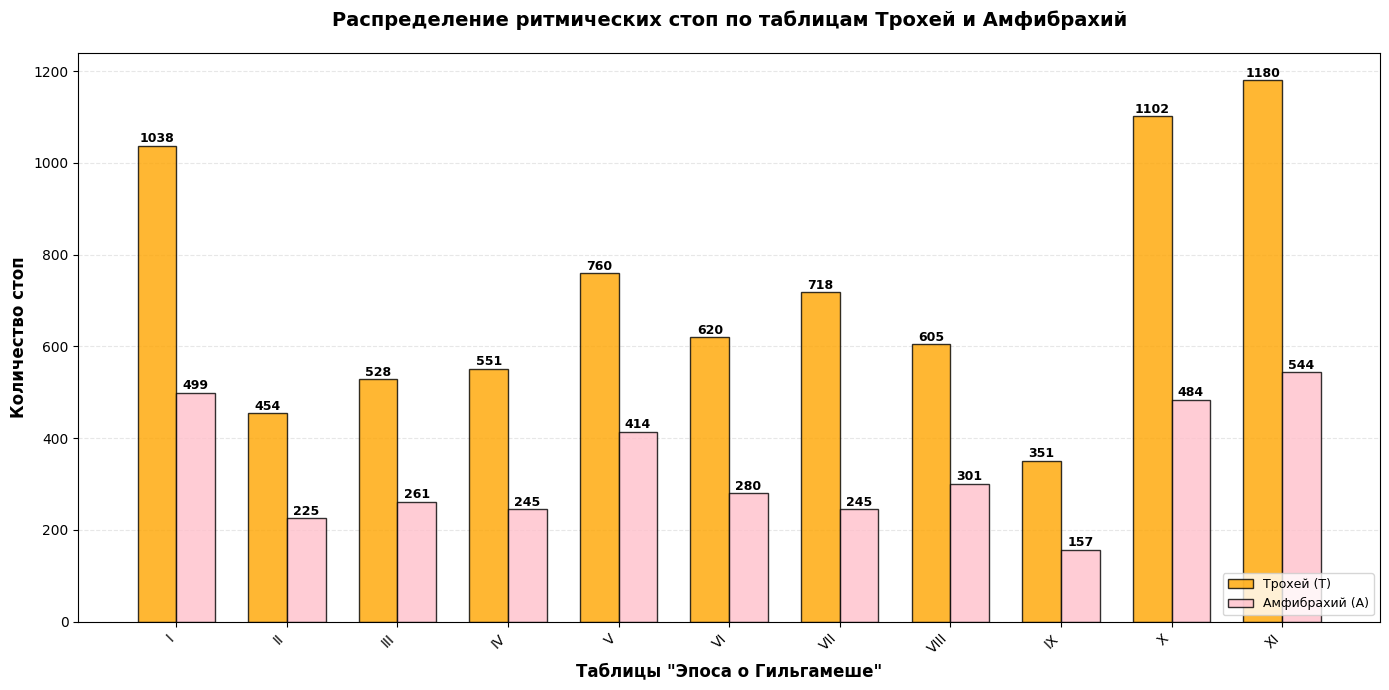


Общая статистика для каждой таблицы:

Таблица I: T=1038 (67.5%), A=499 (32.5%)
Таблица II: T=454 (66.9%), A=225 (33.1%)
Таблица III: T=528 (66.9%), A=261 (33.1%)
Таблица IV: T=551 (69.2%), A=245 (30.8%)
Таблица V: T=760 (64.7%), A=414 (35.3%)
Таблица VI: T=620 (68.9%), A=280 (31.1%)
Таблица VII: T=718 (74.6%), A=245 (25.4%)
Таблица VIII: T=605 (66.8%), A=301 (33.2%)
Таблица IX: T=351 (69.1%), A=157 (30.9%)
Таблица X: T=1102 (69.5%), A=484 (30.5%)
Таблица XI: T=1180 (68.4%), A=544 (31.6%)


2: Общая статистика по всем таблицам


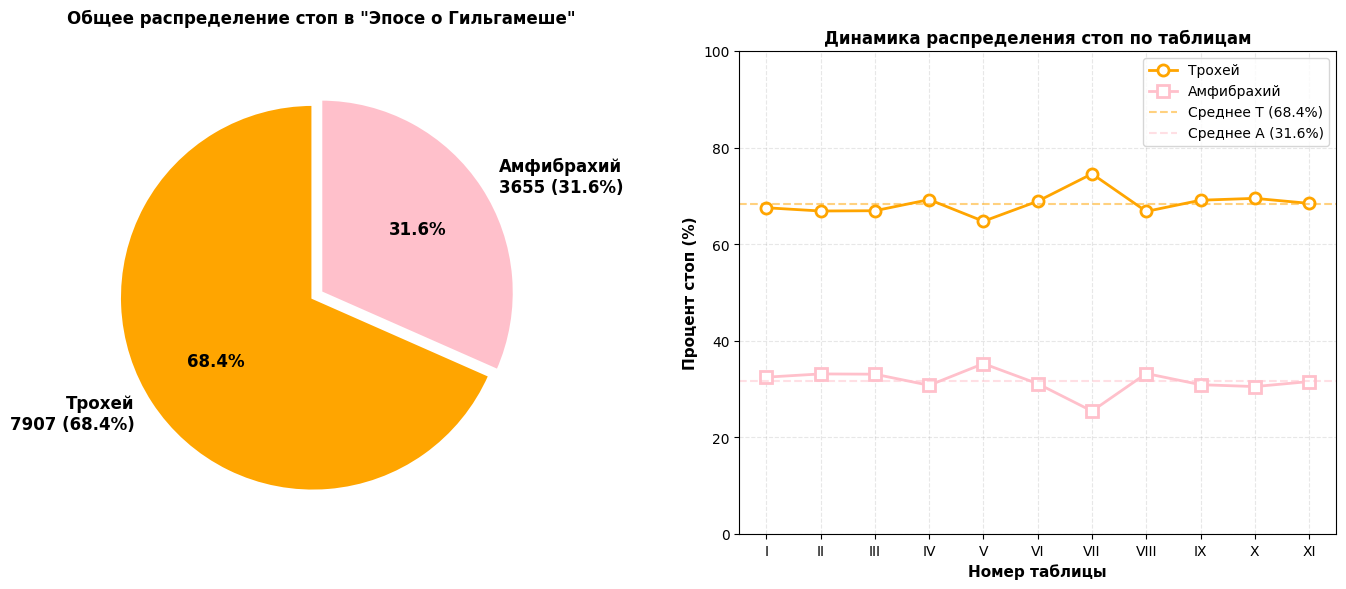


Общая статистика по всем таблицам:

Всего стоп: 11562
Трохей: 7907 (68.39%)
Амфибрахий: 3655 (31.61%)
Соотношение Трохея к Амфибрахию = 2.163:1

Общий анализ стоп

Переходы между стопами (биграммы):
  T → T: 5436 раз (47.0%)
  T → A: 2471 раз (21.4%)
  A → T: 2470 раз (21.4%)
  A → A: 1184 раз (10.2%)


In [17]:
#изображение
print()
print("Визуализация статистики по стопам в Эпосе")
print()

#сбор статистики из обработанных файлов
tablet_stats, all_feet = parse_processed_files_for_stats()

if tablet_stats:
    #распределение по таблицам
    print("1: Распределение типов стоп  по таблицам")
    plot_feet_distribution(tablet_stats)
    print()
    print()
    #общая статистика
    print("2: Общая статистика по всем таблицам")
    plot_overall_statistics(tablet_stats, all_feet)

## Интерпретация результатов по ритмическому анализу "Эпоса о Гильгамеше"

### Анализ полученных данных

В результате работы программы были обработаны 11 таблиц "Эпоса о Гильгамеше" (таблицы I-XI). Для каждой строки были выделены слоги, определены их типы (L/H/U), расставлены ударения и произведено дробление на ритмические стопы (трохей и амфибрахий).

**Важные моменты:**

1. **Преобладание трохея над амфибрахием**
   - Во всех таблицах количество трохеев значительно превышает количество амфибрахиев и соотношние T к A составляет примерно 2:1 или 3:1 в зависимости от таблицы
   - Из этого можно сделать вывод, что трохейный ритм более свойственен для гимно-эпического жанра

2. **Вариативность между таблицами**
   - Можно заметить динамику распределения стоп от таблицы к таблице, из этого можно заключить об единой ритмической организации текста

3. **Переходы между стопами**
   - Наиболее частотным является переход T→T (трохей за трохеем), а переходы A→A встречаются реже всего
   - Из этого должно создваться ритмическая плавность и инерция

### Интерпретация с филологической точки зрения
Из полученых результатов, можно однозначно сказать, что таблицы 1-11 Эпоса написаны в гимно-эпическом жанре с соблюдением ритмических закономерностей. Преобладание трохея над амфибрахием характерно для аккадской поэзии, где трохеический ритм создает более энергичное, повествовательное звучание, в то время как амфибрахий используется для выделения отдельных смысловых акцентов. И можно также заключить единную композицию в таблицах 1-11.

### Ограничения метода
Можно выделить ряд сложностей:
1. **Проблема лакун и неполных восстановлений**
   - Исходные JSON-файлы содержат лакуны, программа пропускает строки без аккадских слов, и это приводит к неполноте статистики для некоторых строк

2. **Сложности с энклитиками (-ma)**
   - Энклитики  относятся к стоп-словам и не несут ударения, но однако в некоторых случаях они могут влиять на ритмическую структуру
   - В самом коде энклитики исключены из анализа, что может упрощать реальную картину

3. **Отсутствие музыкального аспекта**
   - Известно, что чаще всего аккадские гимно-эпические текты исполнялась под музыку, анализ учитывает только тихосложение, а не музыкальную ритмику
   - К сожалению, информации о музыкальном исполнении аккадских текстов не сохранились (либо еще не найдено)

4. **Проблема диахронности версий**
   - Программа анализирует только стандартовавилонскую версию,так как она является самой полной, но не учитываются другие версии, также стоит отметить, что для каждого периода аккадского языка свойственны свои ритмические нормы

5. **Субъективность деления на слоги**
   - В некоторых случаях деление на слоги может быть неоднозначным, как например, сочетания согласных на стыке морфем
   - Программа использует упрощенные правила, которые не покрывают все случаи

6. **Игнорирование просодических особенностей**
   - Не учитывается долгота гласных в поэтической речи
   - Не обрабатываются случаи элизии (стяжения гласных на стыке слов)
   - В реальном исполнении некоторые безударные слоги могли "исчезать"

### Перспективы развития
Данный код может быть улучшен:

1. **Сравнение с другими аккадскими текстами**
   - Применить алгоритм к "Эпосу об Атрахасисе", "Энума элиш"
   - Сравнение разных жанров (гимн, плач)
   - Выявить жанрово-специфичные ритмические маркеры

2. **Расширение функциональности**
   - Визуализировать ритмическую структуру в реальном времени
   - Предоставить возможность экспорта результатов в разных форматах

3. **Сравнение с таблицей XII**
   - Проанализировать таблицу XII (которая сейчас пропускается программой)
   - Количественно подтвердить/опровергнуть гипотезу о прозаическом характере
   - Показать разницу в ритмических показателях

4. **Статистический анализ**
   - Выявить повторяющиеся ритмические формулы и сопоставить их с известными формулами устной поэзии

5. **Создание лемматизированного корпуса аккадского языка**
   - Создание морфологическую разметку (части речи, падежи)
   - Исследовать корреляцию между ритмом и грамматическими категориями
   - Выявить ритмические маркеры границы предложений

### Заключение

Разработанная программа справляется с поставлеными задачами и целью с анализом "Эпоса о гильгамеше". Результаты доказывают гимно-эпическую жарн и однородность таблиц 1-11.